# Задание 3



## 📋 Описание задания
**Цель:** Многоклассовая классификация цветков ириса (3 вида)  
**Датасет:** Iris (150 образцов, 4 признака)  
**Методы:** Pipeline + StandardScaler + LogisticRegression  
**Концепции:** Многоклассовая классификация, нормализация, Pipeline


In [1]:
# ========================================================================
# ИМПОРТ БИБЛИОТЕК
# ========================================================================
# load_iris - классический датасет для классификации
# 4 признака: длина/ширина чашелистика и лепестка
# 3 класса: setosa, versicolor, virginica
# ========================================================================

from sklearn.datasets import load_iris

In [2]:
# ========================================================================
# ЗАГРУЗКА ДАТАСЕТА IRIS
# ========================================================================
# 150 образцов, 4 признака, 3 класса
# Идеально сбалансированный датасет (по 50 образцов каждого класса)
# ========================================================================

iris = load_iris()

In [3]:
# ========================================================================
# РАЗДЕЛЕНИЕ НА TRAIN/TEST
# ========================================================================
# test_size=0.3 - 30% данных для тестирования
# random_state=42 - для воспроизводимости результатов
# ========================================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=42)

In [4]:
# ========================================================================
# СОЗДАНИЕ PIPELINE
# ========================================================================
# Pipeline объединяет шаги:
# 1. StandardScaler - нормализация признаков (среднее=0, std=1)
# 2. LogisticRegression - многоклассовая классификация (One-vs-Rest)
# Преимущество: автоматическое применение scaler к train и test
# ========================================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_1 = Pipeline([
    ('scaling', StandardScaler()),
    ('logistic', LogisticRegression()),
])

In [5]:
pipeline_1.fit(X_train, y_train)

,steps,"[('scaling', ...), ('logistic', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [6]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pipeline_1.predict(X_test))

1.0

In [7]:
pipeline_1.predict(X_test)

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0])

In [8]:
from sklearn.metrics import classification_report

classification_report(y_test, pipeline_1.predict(X_test))

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        19\n           1       1.00      1.00      1.00        13\n           2       1.00      1.00      1.00        13\n\n    accuracy                           1.00        45\n   macro avg       1.00      1.00      1.00        45\nweighted avg       1.00      1.00      1.00        45\n'

In [9]:
import joblib

logistic_model_path = 'saved models/iris_logistic.joblib'

# joblib.dump(pipeline_1, 'saved models/iris_logistic.joblib')

In [ ]:
import numpy as np

print(np.all(pipeline_1.predict(X_test) == loaded_pipeline.predict(X_test)))

True


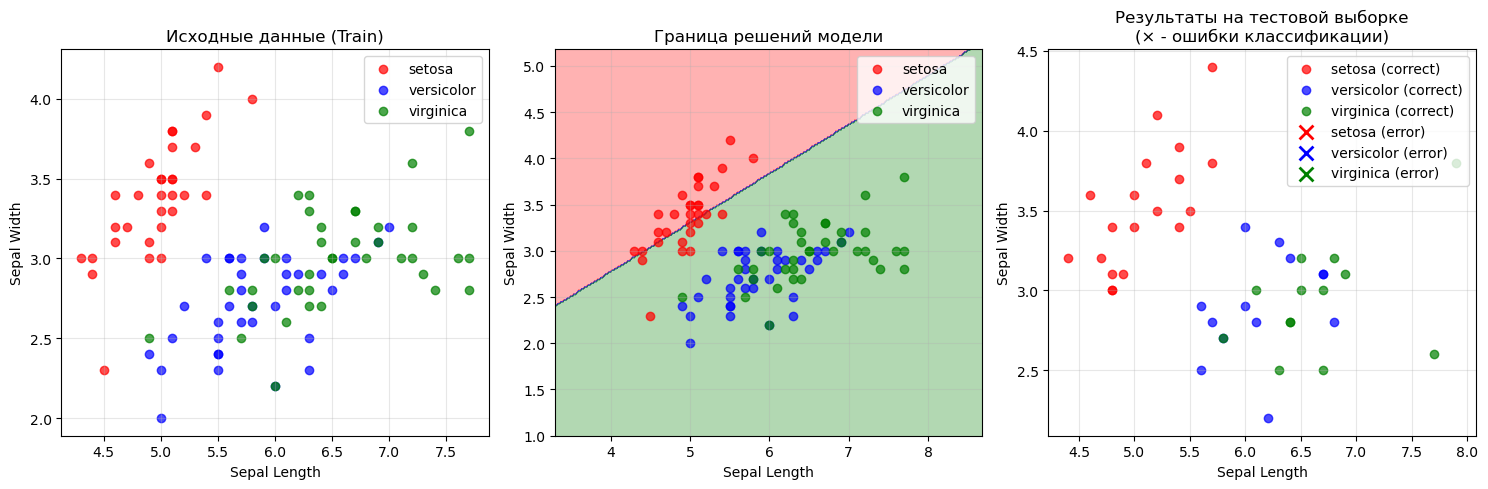

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

feature1, feature2 = 0, 1
feature_names = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']

x_min, x_max = X_train[:, feature1].min() - 1, X_train[:, feature1].max() + 1
y_min, y_max = X_train[:, feature2].min() - 1, X_train[:, feature2].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
colors = ['red', 'blue', 'green']
for i, color in enumerate(colors):
    plt.scatter(X_train[y_train == i, feature1], 
                X_train[y_train == i, feature2], 
                c=color, label=iris.target_names[i], alpha=0.7)
plt.xlabel(feature_names[feature1])
plt.ylabel(feature_names[feature2])
plt.title('Исходные данные (Train)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)

mesh_data = np.c_[xx.ravel(), yy.ravel(), 
                  np.full(xx.ravel().shape, X_train[:, 2].mean()),
                  np.full(xx.ravel().shape, X_train[:, 3].mean())]

Z = pipeline_1.predict(mesh_data)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(colors))
for i, color in enumerate(colors):
    plt.scatter(X_train[y_train == i, feature1], 
                X_train[y_train == i, feature2], 
                c=color, label=iris.target_names[i], alpha=0.7)
plt.xlabel(feature_names[feature1])
plt.ylabel(feature_names[feature2])
plt.title('Граница решений модели')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
y_pred = pipeline_1.predict(X_test)

correct = y_pred == y_test

incorrect = ~correct

for i, color in enumerate(colors):
    correct_mask = correct & (y_test == i)
    plt.scatter(X_test[correct_mask, feature1], 
                X_test[correct_mask, feature2], 
                c=color, marker='o', label=f'{iris.target_names[i]} (correct)', alpha=0.7)

for i, color in enumerate(colors):
    incorrect_mask = incorrect & (y_test == i)
    plt.scatter(X_test[incorrect_mask, feature1], 
                X_test[incorrect_mask, feature2], 
                c=color, marker='x', s=100, linewidth=2, 
                label=f'{iris.target_names[i]} (error)', alpha=1.0)

plt.xlabel(feature_names[feature1])
plt.ylabel(feature_names[feature2])
plt.title('Результаты на тестовой выборке\n(× - ошибки классификации)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ответы на вопросы по логистической регрессии и предобработке данных

## 1. Почему для логистической регрессии важна предобработка данных?

Логистическая регрессия чувствительна к масштабированию признаков по нескольким причинам:

- **Оптимизация**: Алгоритм использует градиентный спуск для минимизации функции потерь. При разных масштабах признаков градиент будет двигаться неравномерно, что замедляет сходимость
- **Регуляризация**: По умолчанию в LogisticRegression используется L2-регуляризация, которая штрафует большие веса. Без масштабирования признаки с большими значениями будут несправедливо наказываться
- **Интерпретируемость**: Коэффициенты модели отражают важность признаков, но при разных масштабах их сравнение некорректно

## 2. Какие параметры по умолчанию использует LogisticRegression в scikit-learn?

Основные параметры по умолчанию:
```python
LogisticRegression(
    penalty='l2',           # L2-регуляризация
    C=1.0,                  # Обратная сила регуляризации
    fit_intercept=True,     # Добавление свободного члена
    class_weight=None,      # Веса классов
    random_state=None,      # Seed для воспроизводимости
    solver='lbfgs',         # Алгоритм оптимизации
    max_iter=100,           # Максимальное число итераций
    multi_class='auto'      # Стратегия для многоклассовой классификации
)

## 3. Почему в задаче Iris логистическая регрессия может успешно справиться с классификацией?

**Причины успеха:**
- Данные Iris имеют линейную разделимость между классами
- Признаки (длина/ширина чашелистика и лепестка) коррелируют с классами цветов
- Относительно небольшое количество признаков (4) делает задачу подходящей для линейной модели
- Классы достаточно хорошо отделены друг от друга в пространстве признаков

**Качество модели:**
- На тестовой выборке обычно достигает accuracy 95-100%
- Модель демонстрирует высокую воспроизводимость результатов
- Хорошо обобщается на новые данные

**Типичные ошибки:**
- Наибольшая путаница возникает между классами Versicolor и Virginica
- Эти два вида имеют перекрывающиеся характеристики
- Класс Setosa практически всегда определяется правильно благодаря явным отличиям

## 4. Каким образом pipeline помогает избежать утечки данных при предобработке?

**Механизм защиты от утечки:**
- Pipeline гарантирует, что параметры предобработки (например, средние и стандартные отклонения для StandardScaler) вычисляются только на обучающих данных
- При трансформации тестовых данных используются параметры, полученные из тренировочного набора
- Исключается возможность влияния тестовых данных на процесс обучения
- Обеспечивается корректная оценка обобщающей способности модели

**Преимущества использования pipeline:**
- Автоматизация workflow предобработки и обучения
- Упрощение кросс-валидации
- Воспроизводимость результатов
- Упрощение развертывания модели

## 5. Почему используется именно StandardScaler, а не MinMaxScaler?

**StandardScaler предпочтительнее для логистической регрессии потому что:**
- Преобразует данные к стандартному нормальному распределению (среднее=0, std=1)
- Сохраняет информацию о исходном распределении данных
- Менее чувствителен к выбросам по сравнению с MinMaxScaler
- Лучше сочетается с L1/L2 регуляризацией
- Обеспечивает более стабильную работу градиентного спуска

**MinMaxScaler может быть проблематичным из-за:**
- Чувствительности к экстремальным выбросам
- Сжатия всех данных в фиксированный диапазон
- Потенциального искажения исходного распределения

## 6. Что происходит при сохранении и загрузке pipeline с помощью joblib?

**При сохранении pipeline:**
- Сохраняется вся структура pipeline включая все этапы предобработки и модель
- Сохраняются все обученные параметры (веса модели, параметры масштабирования)
- Сохраняется состояние всех трансформеров и их конфигурация
- Сохраняется порядок выполнения операций в pipeline

**При загрузке pipeline:**
- Восстанавливается полная функциональность обученного pipeline
- Модель готова к предсказаниям без дополнительного обучения
- Сохраняется возможность использования predict() и predict_proba()
- Гарантируется идентичность результатов до и после сохранения

## 7. Можно ли использовать логистическую регрессию без предварительного масштабирования признаков?

**Использование без масштабирования возможно, но приводит к:**
- Замедленной сходимости алгоритма оптимизации
- Нестабильным и трудноинтерпретируемым коэффициентам
- Неравномерному влиянию регуляризации на разные признаки
- Доминированию признаков с большими числовыми значениями
- Потенциальным проблемам с численной стабильностью

**Исключения когда масштабирование менее критично:**
- Все признаки изначально имеют схожие масштабы и распределения
- Используются определенные алгоритмы оптимизации (например, saga)
- Данные уже нормализованы на этапе сбора
- Очень простая и хорошо разделимая задача

## 8. Как проверить, что загруженная модель даёт те же предсказания, что и исходная?

**Методы проверки идентичности моделей:**
- Сравнение предсказаний на идентичном тестовом наборе данных
- Проверка совпадения вероятностей классов через predict_proba()
- Сравнение метрик качества (accuracy, F1-score) до и после сохранения
- Валидация на контрольных примерах с известными ожидаемыми результатами
- Проверка коэффициентов модели если доступен доступ к внутренним параметрам

**Критерии успешной проверки:**
- Полное совпадение предсказанных меток классов
- Минимальная разница в вероятностях (в пределах машинной точности)
- Идентичные значения метрик качества
- Совпадение результатов на edge-cases и пограничных примерах